# Prototype: CNN + Grad-CAM on CBIS-DDSM subset

## Import Libraries

In [1]:
# %%
# Prototype: CNN + Grad-CAM on CBIS-DDSM subset

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
from torchvision import transforms

# Make project root importable
ROOT_DIR = os.path.abspath(os.path.join(".."))
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

from utils.dataset import CBISDicomDataset  # you'll create/adjust this
from utils.transforms import get_preprocessing_transforms
from utils.gradcam import GradCAM

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## Paths

In [2]:
RAW_ROOT = os.path.join(ROOT_DIR, "data", "raw", "CBIS-DDSM-All-doiJNLP-zzWs5zfZ", "cbis_ddsm")
METADATA_MASS_TRAIN = os.path.join(ROOT_DIR, "data", "raw", "mass_case_description_train_set.csv")
METADATA_MASS_TEST = os.path.join(ROOT_DIR, "data", "raw", "mass_case_description_test_set.csv")

print(RAW_ROOT)
print(METADATA_MASS_TRAIN)

/Users/gibionmakiwa/MyDocuments/610MtSundanceBayW/University_of_London_Computer_Science_BSc/CM3070 Computer Science Final Project/multimodal-mammography-xai/data/raw/CBIS-DDSM-All-doiJNLP-zzWs5zfZ/cbis_ddsm
/Users/gibionmakiwa/MyDocuments/610MtSundanceBayW/University_of_London_Computer_Science_BSc/CM3070 Computer Science Final Project/multimodal-mammography-xai/data/raw/mass_case_description_train_set.csv


## Load metadata and build a small prototype subset (e.g., 200 cases)

In [3]:
CSV_PATH = os.path.join(
    ROOT_DIR,
    "data",
    "raw",
    "CBIS-DDSM-All-doiJNLP-zzWs5zfZ",
    "metadata",
    "mass_train_with_dicom_paths.csv"
)

meta = pd.read_csv(CSV_PATH)

# Keep only rows that have a valid DICOM path
meta = meta[meta["actual_dicom_path"].notna()].reset_index(drop=True)

# Sample 200 for prototype
meta_subset = meta.sample(n=500, random_state=42).reset_index(drop=True)

# Ensure label is binary
meta_subset["label"] = (meta_subset["pathology"] == "MALIGNANT").astype(int)

meta_subset.head()


,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,tcia_folder,actual_dicom_path,label
0,P_00976,1,LEFT,MLO,1,mass,IRREGULAR,OBSCURED,0,BENIGN,2,Mass-Training_P_00976_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00976_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00976_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00976_LEFT_MLO_1,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...,0
1,P_01394,2,RIGHT,MLO,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Training_P_01394_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_01394_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_01394_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_01394_RIGHT_MLO_1,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...,1
2,P_00871,2,LEFT,CC,1,mass,IRREGULAR,ILL_DEFINED,4,MALIGNANT,3,Mass-Training_P_00871_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00871_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00871_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00871_LEFT_CC,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...,1
3,P_00068,3,RIGHT,CC,1,mass,IRREGULAR,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00068_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_00068_RIGHT_CC_1/1.3.6.1.4.1.9...,Mass-Training_P_00068_RIGHT_CC_1/1.3.6.1.4.1.9...,Mass-Training_P_00068_RIGHT_CC_1,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...,1
4,P_01849,1,RIGHT,MLO,1,mass,LYMPH_NODE,NaN,2,BENIGN_WITHOUT_CALLBACK,3,Mass-Training_P_01849_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_01849_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_01849_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_01849_RIGHT_MLO,/Users/gibionmakiwa/MyDocuments/610MtSundanceB...,0


## Inspect how DICOM paths are encoded in metadata

In [4]:
# %%
# Inspect how DICOM paths are encoded in metadata

meta_subset[["patient_id", "image file path", "label"]].head()

,patient_id,image file path,label
0,P_00976,Mass-Training_P_00976_LEFT_MLO/1.3.6.1.4.1.959...,0
1,P_01394,Mass-Training_P_01394_RIGHT_MLO/1.3.6.1.4.1.95...,1
2,P_00871,Mass-Training_P_00871_LEFT_CC/1.3.6.1.4.1.9590...,1
3,P_00068,Mass-Training_P_00068_RIGHT_CC/1.3.6.1.4.1.959...,1
4,P_01849,Mass-Training_P_01849_RIGHT_MLO/1.3.6.1.4.1.95...,0


## Create PyTorch Dataset using utils/dataset.py

In [5]:
# %%
# Create PyTorch Dataset using your utils/dataset.py

from torch.utils.data import random_split

transform = get_preprocessing_transforms()  # from utils/transforms.py

train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor()
])

val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor()
])


full_dataset = CBISDicomDataset(
    metadata=meta_subset,
    load_masks=True
)

len(full_dataset)

500

## Split into train/val for the prototype

In [6]:
# %%
# Split into train/val for the prototype

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
#train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
train_dataset = CBISDicomDataset(metadata=meta_subset.iloc[:160], load_masks=True)
val_dataset = CBISDicomDataset(metadata=meta_subset.iloc[160:], load_masks=True)

train_dataset.transform = train_transforms
val_dataset.transform = val_transforms

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

len(train_dataset), len(val_dataset)

(160, 340)

## Visual sanity check: show one sample

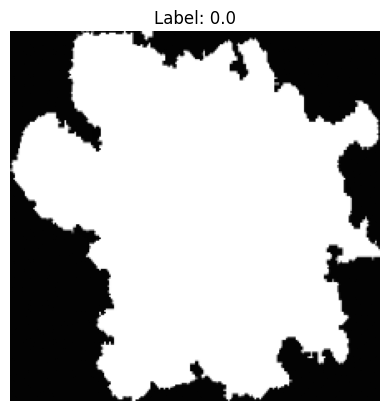

In [7]:
# %%
# Visual sanity check: show one sample

img, mask, label = full_dataset[0]

plt.imshow(np.transpose(img.numpy(), (1, 2, 0)), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

## Build and configure ResNet50

In [8]:
# %%
# Build and configure ResNet50

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
#num_features = resnet.fc.in_features
#resnet.fc = nn.Linear(num_features, 1)
num_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Dropout(p=0.5),  # 50% dropout
    nn.Linear(num_features, 1)
)

resnet = resnet.to(device)

criterion = nn.BCEWithLogitsLoss()
#optimizer = torch.optim.Adam(resnet.parameters(), lr=1e-4)
optimizer = torch.optim.Adam(resnet.parameters(), lr=1e-4, weight_decay=1e-5)

## Training loop (prototype: ~5–10 epochs)

In [9]:
# %%
# Training loop (prototype: ~5–10 epochs)

from tqdm.auto import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for imgs, masks, labels in tqdm(loader, desc="Train", leave=False):
        imgs = imgs.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = model(imgs).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_outputs = []
    all_labels = []

    with torch.no_grad():
        for imgs, masks, labels in tqdm(loader, desc="Val", leave=False):
            imgs = imgs.to(device)
            labels = labels.float().to(device)

            outputs = model(imgs).squeeze(1)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            all_outputs.append(outputs.cpu())
            all_labels.append(labels.cpu())

    all_outputs = torch.cat(all_outputs)
    all_labels = torch.cat(all_labels)

    probs = torch.sigmoid(all_outputs)
    preds = (probs > 0.5).int()
    acc = (preds == all_labels.int()).float().mean().item()

    return running_loss / len(loader.dataset), acc


EPOCHS = 10
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(resnet, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(resnet, val_loader, criterion, device)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f}")


Train:   0%|          | 0/10 [00:00<?, ?it/s]

Val:   0%|          | 0/22 [00:12<?, ?it/s]

/Users/gibionmakiwa/MyDocuments/610MtSundanceBayW/University_of_London_Computer_Science_BSc/CM3070 Computer Science Final Project/multimodal-mammography-xai/utils/dataset.py:19: RuntimeWarning: invalid value encountered in divide
  img_uint8 = (img / img.max() * 255).astype("uint8")
/Users/gibionmakiwa/MyDocuments/610MtSundanceBayW/University_of_London_Computer_Science_BSc/CM3070 Computer Science Final Project/multimodal-mammography-xai/utils/dataset.py:19: RuntimeWarning: invalid value encountered in cast
  img_uint8 = (img / img.max() * 255).astype("uint8")


Epoch 1/10 | Train Loss: 0.6835 | Val Loss: 0.6991 | Val Acc: 0.479


Train:   0%|          | 0/10 [00:02<?, ?it/s]

...

Epoch 9/10 | Train Loss: 0.1490 | Val Loss: 1.2867 | Val Acc: 0.512


Train:   0%|          | 0/10 [00:00<?, ?it/s]

Val:   0%|          | 0/22 [00:19<?, ?it/s]

/Users/gibionmakiwa/MyDocuments/610MtSundanceBayW/University_of_London_Computer_Science_BSc/CM3070 Computer Science Final Project/multimodal-mammography-xai/utils/dataset.py:19: RuntimeWarning: invalid value encountered in divide
  img_uint8 = (img / img.max() * 255).astype("uint8")
/Users/gibionmakiwa/MyDocuments/610MtSundanceBayW/University_of_London_Computer_Science_BSc/CM3070 Computer Science Final Project/multimodal-mammography-xai/utils/dataset.py:19: RuntimeWarning: invalid value encountered in cast
  img_uint8 = (img / img.max() * 255).astype("uint8")


Epoch 10/10 | Train Loss: 0.0910 | Val Loss: 1.4673 | Val Acc: 0.524


## Save prototype model

In [10]:
## # %%
# Save prototype model

os.makedirs(os.path.join(ROOT_DIR, "models"), exist_ok=True)
MODEL_PATH = os.path.join(ROOT_DIR, "models", "resnet50_prototype.pth")
torch.save(resnet.state_dict(), MODEL_PATH)
MODEL_PATH


'/Users/gibionmakiwa/MyDocuments/610MtSundanceBayW/University_of_London_Computer_Science_BSc/CM3070 Computer Science Final Project/multimodal-mammography-xai/models/resnet50_prototype.pth'

## Grad-CAM: use utils/gradcam.py

In [11]:
# %%
# Grad-CAM: use your utils/gradcam.py

# We assume utils/gradcam.py defines a GradCAM class similar to:
# GradCAM(model, target_layer)

target_layer = resnet.layer4[-1]
gradcam = GradCAM(resnet, target_layer, device=device)


## Pick a validation sample and generate Grad-CAM

/usr/local/lib/python3.8/site-packages/torch/nn/modules/module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


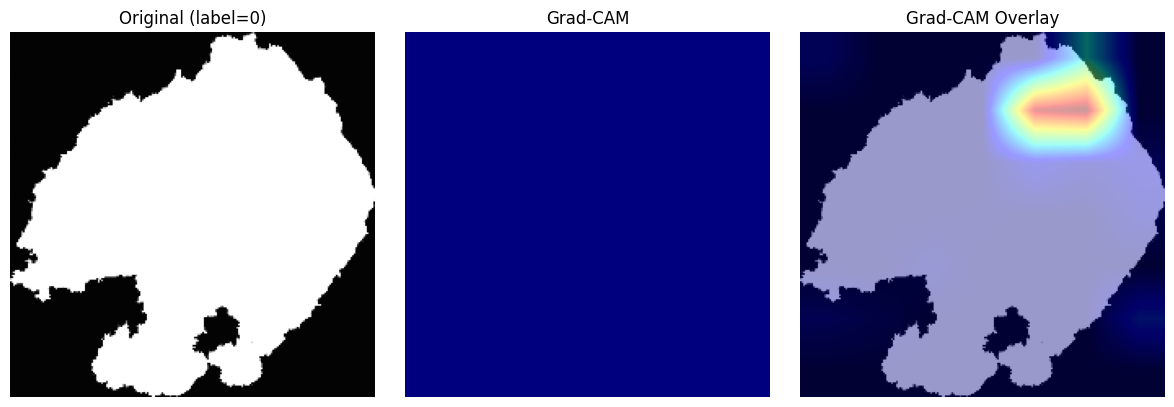

In [12]:
# %%
# Pick a validation sample and generate Grad-CAM

resnet.eval()

img, mask, label = val_dataset[0]
input_tensor = img.unsqueeze(0).to(device)

cam = gradcam(input_tensor)  # expected shape: (H, W) normalised 0–1

# Convert original image back to HxW or HxWx3 for overlay
img_np = img.permute(1,2,0).numpy()

mask_np = mask.squeeze().numpy()

#heatmap = plt.cm.jet(cam)[..., :3]  # RGB
#overlay = 0.4 * heatmap + 0.6 * img_np

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_np, cmap="gray")
plt.title(f"Original (label={int(label)})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_np, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_np, cmap="gray")
plt.imshow(cam, cmap="jet", alpha=0.4)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()


## Loop over several samples and save Grad-CAM overlays to results/heatmaps

In [13]:
# %%
# (Optional) Loop over several samples and save Grad-CAM overlays to results/heatmaps

HEATMAP_DIR = os.path.join(ROOT_DIR, "results", "heatmaps")
os.makedirs(HEATMAP_DIR, exist_ok=True)

for i in range(10):
    img, mask, label = val_dataset[i]
    input_tensor = img.unsqueeze(0).to(device)
    cam = gradcam(input_tensor)

    img_np = np.transpose(img.numpy(), (1, 2, 0))
    img_np = img_np / img_np.max()
    heatmap = plt.cm.jet(cam)[..., :3]
    heatmap = heatmap / heatmap.max()
    #overlay = 0.4 * heatmap + 0.6 * img_np
    #overlay = np.clip(overlay, 0, 1)
    overlay = np.clip(0.4 * heatmap + 0.6 * img_np, 0, 1)

    plt.imsave(os.path.join(HEATMAP_DIR, f"sample_{i}_overlay_label_{int(label)}.png"), overlay)
